In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import re
import shutil
import string
import tensorflow as tf
from tensorflow.keras import layers, losses
from tensorflow.keras.utils import get_file

In [21]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/stack_overflow_16k.tar.gz"

dataset = get_file("stack_overflow_16k", url,
                                    untar=True, cache_dir='data',
                                    cache_subdir='stack_overflow_16k')


6053168/6053168 [==============================] - 1s 0us/step


In [23]:
dataset_dir = os.path.dirname(dataset)
os.listdir(dataset_dir)

['README.md', 'stack_overflow_16k.tar.gz', 'test', 'train']

In [24]:
train_dir = os.path.join(dataset_dir, 'train')
os.listdir(train_dir)

['csharp', 'java', 'javascript', 'python']

In [30]:
sample_file = os.path.join(train_dir, 'java/2.txt')
with open(sample_file) as f:
  print(f.read())

"identifier required when invoking a private method i am calling a private method for testing and for that i am using the following code to invoke private method. repeat() is the private method of class diamond..import org.junit.test;.import static org.junit.assert.*;.import blank.lang.stringbuilder;.import blank.lang.reflect.method;.public class diamondunit {.        stringbuilder expect = new stringbuilder();.        diamond test = new diamond();.        method m = test.getclass().getdeclaredmethod(""repeat"");.        m.setaccessible(true);.        m.invoke(test);..    @test.        public void testrepeatneg() {.            assertequals("""", test.repeat(expect,""a"",-1));.        }.}...while compiling it is giving error ..diamondunit.blank:11: error: expected.m.setaccessible(true);.^.diamondunit.blank:11: error: illegal start of type.m.setaccessible(true);.^.diamondunit.blank:12: error: expected.m.invoke(test);.^.diamondunit.blank:12: error: expected.m.invoke(test);.^...i had cop p

In [31]:
batch_size = 32
seed = 42

raw_train_ds = tf.keras.utils.text_dataset_from_directory(
    'data/stack_overflow_16k/train', 
    batch_size=batch_size, 
    validation_split=0.2, 
    subset='training', 
    seed=seed)

Found 8000 files belonging to 4 classes.
Using 6400 files for training.


In [32]:
for text_batch, label_batch in raw_train_ds.take(1):
  for i in range(3):
    print("Review:", text_batch.numpy()[i])
    print("Label:", label_batch.numpy()[i], f'({raw_train_ds.class_names[i]})')

Review: b'"my tester is going to the wrong constructor i am new to programming so if i ask a question that can be easily fixed, please forgive me. my program has a tester class with a main. when i send that to my regularpolygon class, it sends it to the wrong constructor. i have two constructors. 1 without perameters..public regularpolygon().    {.       mynumsides = 5;.       mysidelength = 30;.    }//end default constructor...and my second, with perameters. ..public regularpolygon(int numsides, double sidelength).    {.        mynumsides = numsides;.        mysidelength = sidelength;.    }// end constructor...in my tester class i have these two lines:..regularpolygon shape = new regularpolygon(numsides, sidelength);.        shape.menu();...numsides and sidelength were declared and initialized earlier in the testing class...so what i want to happen, is the tester class sends numsides and sidelength to the second constructor and use it in that class. but it only uses the default constr

In [33]:
print("Label 0 corresponds to", raw_train_ds.class_names[0])
print("Label 1 corresponds to", raw_train_ds.class_names[1])
print("Label 2 corresponds to", raw_train_ds.class_names[2])
print("Label 3 corresponds to", raw_train_ds.class_names[3])

Label 0 corresponds to csharp
Label 1 corresponds to java
Label 2 corresponds to javascript
Label 3 corresponds to python


In [34]:
raw_val_ds = tf.keras.utils.text_dataset_from_directory(
    'data/stack_overflow_16k/train', 
    batch_size=batch_size, 
    validation_split=0.2, 
    subset='validation', 
    seed=seed)

Found 8000 files belonging to 4 classes.
Using 1600 files for validation.


In [35]:
raw_test_ds = tf.keras.utils.text_dataset_from_directory(
    'data/stack_overflow_16k/test', 
    batch_size=batch_size)

Found 8000 files belonging to 4 classes.


In [36]:
def custom_standardization(input_data):
  lowercase = tf.strings.lower(input_data)
  stripped_html = tf.strings.regex_replace(lowercase, '<br />', ' ')
  return tf.strings.regex_replace(stripped_html,
                                  '[%s]' % re.escape(string.punctuation),
                                  '')

In [37]:
max_features = 10000
sequence_length = 250

vectorize_layer = layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length)

In [38]:
# Make a text-only dataset (without labels), then call adapt
train_text = raw_train_ds.map(lambda x, y: x)
vectorize_layer.adapt(train_text)

In [39]:
def vectorize_text(text, label):
  text = tf.expand_dims(text, -1)
  return vectorize_layer(text), label

In [40]:
# retrieve a batch (of 32 reviews and labels) from the dataset
text_batch, label_batch = next(iter(raw_train_ds))
first_review, first_label = text_batch[0], label_batch[0]
print("Review", first_review)
print("Label", raw_train_ds.class_names[first_label])
print("Vectorized review", vectorize_text(first_review, first_label))

Review tf.Tensor(b'"set blank to quit on exception? i\'m using blank 3..i\'ve been looking around for an answer to this, but i haven\'t found it yet. basically, i\'m running several blank scripts into a game engine, and each script has its own entry point...i\'d rather not add try: except blocks through all of my code, so i was wondering if it\'s at all possible to tell blank to quit (or perhaps assign a custom function to that ""callback"") on finding its first error, regardless of where or what it found? ..currently, the game engine will continue after finding and hitting an error, making it more difficult than necessary to diagnose issues since running into one error may make a subsequent script not work (as it relies on variables that the error-ing script set, for example). any ideas? ..i know that i could redirect the console to a file to allow for easier scrolling, but just capturing the first error and stopping the game prematurely would be really useful...okay, a couple of extr

In [41]:
print("1287 ---> ",vectorize_layer.get_vocabulary()[1287])
print(" 313 ---> ",vectorize_layer.get_vocabulary()[313])
print('Vocabulary size: {}'.format(len(vectorize_layer.get_vocabulary())))

1287 --->  scissors
 313 --->  source
Vocabulary size: 10000


In [42]:
train_ds = raw_train_ds.map(vectorize_text)
val_ds = raw_val_ds.map(vectorize_text)
test_ds = raw_test_ds.map(vectorize_text)

In [43]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [44]:
embedding_dim = 16
model = tf.keras.Sequential([
  layers.Embedding(max_features + 1, embedding_dim),
  layers.Dropout(0.2),
  layers.GlobalAveragePooling1D(),
  layers.Dropout(0.2),
  layers.Dense(4)])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 16)          160016    
                                                                 
 dropout (Dropout)           (None, None, 16)          0         
                                                                 
 global_average_pooling1d (  (None, 16)                0         
 GlobalAveragePooling1D)                                         
                                                                 
 dropout_1 (Dropout)         (None, 16)                0         
                                                                 
 dense (Dense)               (None, 4)                 68        
                                                                 
Total params: 160084 (625.33 KB)
Trainable params: 160084 (625.33 KB)
Non-trainable params: 0 (0.00 Byte)
________________

In [45]:
model.compile(loss=losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer='adam',
              metrics=['accuracy'])

In [46]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/10
200/200 [==============================] - 3s 12ms/step - loss: 1.3785 - accuracy: 0.3450 - val_loss: 1.3654 - val_accuracy: 0.5244
Epoch 2/10
200/200 [==============================] - 0s 2ms/step - loss: 1.3457 - accuracy: 0.4762 - val_loss: 1.3212 - val_accuracy: 0.5475
Epoch 3/10
200/200 [==============================] - 0s 2ms/step - loss: 1.2887 - accuracy: 0.5453 - val_loss: 1.2558 - val_accuracy: 0.5863
Epoch 4/10
200/200 [==============================] - 0s 2ms/step - loss: 1.2158 - accuracy: 0.5813 - val_loss: 1.1816 - val_accuracy: 0.6175
Epoch 5/10
200/200 [==============================] - 0s 2ms/step - loss: 1.1391 - accuracy: 0.6281 - val_loss: 1.1082 - val_accuracy: 0.6612
Epoch 6/10
200/200 [==============================] - 0s 2ms/step - loss: 1.0667 - accuracy: 0.6700 - val_loss: 1.0412 - val_accuracy: 0.7006
Epoch 7/10
200/200 [==============================] - 0s 2ms/step - loss: 0.9995 - accuracy: 0.7053 - val_loss: 0.9808 - val_accuracy: 0.7256
Epoch

In [47]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

250/250 [==============================] - 6s 24ms/step - loss: 0.8669 - accuracy: 0.7304
Loss:  0.8669160604476929
Accuracy:  0.7303749918937683


In [48]:
history_dict = history.history
history_dict.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

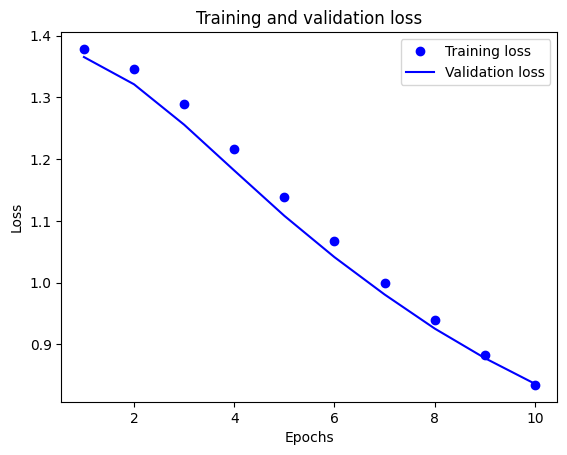

In [49]:
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

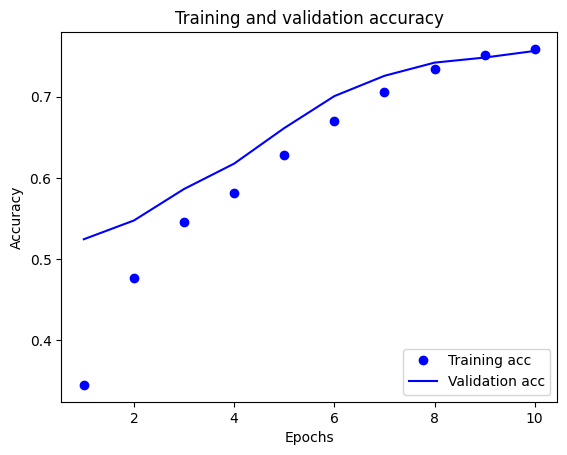

In [50]:
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()

In [51]:
export_model = tf.keras.Sequential([
  vectorize_layer,
  model,
  layers.Activation('sigmoid')
])

export_model.compile(
    loss=losses.SparseCategoricalCrossentropy(from_logits=False), optimizer="adam", metrics=['accuracy']
)

# Test it with `raw_test_ds`, which yields raw strings
loss, accuracy = export_model.evaluate(raw_test_ds)
print(accuracy)

250/250 [==============================] - 1s 5ms/step - loss: 0.8669 - accuracy: 0.7304
0.7303749918937683


In [52]:
examples = [
    "how to specify the connection string if the excel file name contains white space?using blank string connstring = ""provider=microsoft.ace.oledb.12.0;data source=d:\data\[proj_resource details 20110118.xlsx];extended properties=excel 12.0"";...i mentioned [ ] still it is throwing exception.how can i solve this problem..plz mention the correct path",
    "http get response parsing in blank and store in a string i have this below response from a http get request..response=you are about to purchase abcd package for 20 usd. charge :1usd&amp;encoding=0&amp;sessionop=end...i'm trying to get only ""you are about to purchase abcd package for 20 usd. charge :1usd"" to a string in blank so that i can display it to the customer, but i'm not sure how...any help would be appreciated. thank you",
    "why is length equal to 0 in browser before it is defined? i would expect the value of an undefined variable in blank to behave like this when it is logged:....but on jsfiddle it is showing the length is 0 before it is ever defined.....after more research. it also seems to default to 0 in chrome.....when i would expect it to generate an error like with any other randomword....when i run the same commands in node locally, it seems to behave how i would expect. with throwing an error for length:....why is length equal to 0 in these cases?",
    "variables keep changing back to their original value inside a while loop i am doing the mitx 6.00.01x course and i am on the second problem set on the 3rd problem and i am stuck. .my code:  ..    balance = 320000.    annualinterestrate = 0.2.    monthlyinterestrate = (annualinterestrate) / 12.0.    monthlyfixedpayment = 0.    empbalance = balance.    lowerbound = round((balance)/12,2).    upperbound = (balance*(1+monthlyinterestrate)**12)/12.    monthlyfixedpayment = round( ( (lowerbound+upperbound)/2) ,2).    while tempbalance != 0: .        monthlyfixedpayment = round( ( (lowerbound+upperbound)/2) ,2)  .        for m in range(12) :.            tempbalance -= monthlyfixedpayment .            tempbalance += (monthlyinterestrate)*(tempbalance).            tempbalance = round(tempbalance,2) .        if tempbalance &gt; 0:.            lowerbound = round(monthlyfixedpayment,2).            tempbalance = balance.        elif tempbalance &lt; 0: .            upperbound = round(monthlyfixedpayment,2).            tempbalance = balance..    print('lowest payment: ' + str(round(monthlyfixedpayment,2)))...my code uses bisection search to generate the monthlyfixedpayment but after i get to the lines at the end that changes the upperbound or lowerbound values and then start the loop again, the lowerbound and upperbound values reset to their values to the ones outside the loop. does anyone knows how to prevent this?"
]

predictions = export_model.predict(examples)
for i in range(0,4):
    print(raw_train_ds.class_names[np.argmax(predictions[i])])

1/1 [==============================] - 0s 95ms/step
csharp
python
javascript
python
